# 01. Time series fundamentals and stationarity

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/01_fundamentals_stationarity.ipynb)

**Module 1.** You will see the parts of a time series, define weak stationarity, test for it with the Augmented Dickey-Fuller (ADF) test, and make a series stationary with differencing and a Box-Cox transform.

**Why this matters for research:** ARIMA assumes a stationary series. If you skip this check, your coefficients and forecast intervals can be wrong without any error message.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def load_energy():
    """Load the daily energy demand file. Local copy first, GitHub copy on Colab."""
    for base in (Path("../data"), Path("data")):
        path = base / "energy_demand_daily.csv"
        if path.exists():
            break
    else:
        path = RAW + "energy_demand_daily.csv"
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df

In [2]:
from statsmodels.tsa.stattools import adfuller


def adf(series, label, regression="c"):
    """Run the Augmented Dickey-Fuller test and print a plain verdict."""
    stat, pvalue, lags, nobs, crit, _ = adfuller(series.dropna(), regression=regression, autolag="AIC")
    verdict = "reject the unit root (looks stationary)" if pvalue < 0.05 else "cannot reject the unit root (looks non-stationary)"
    print(f"{label:<28} ADF = {stat:7.2f}   p = {pvalue:.4f}   lags = {lags:<3} -> {verdict}")

## 1. Core components of temporal data

A time series often has four parts: a **trend** (slow movement), **seasonality** (a fixed repeating pattern), a **cycle** (irregular long swings), and **noise**. Load the data and look at it.

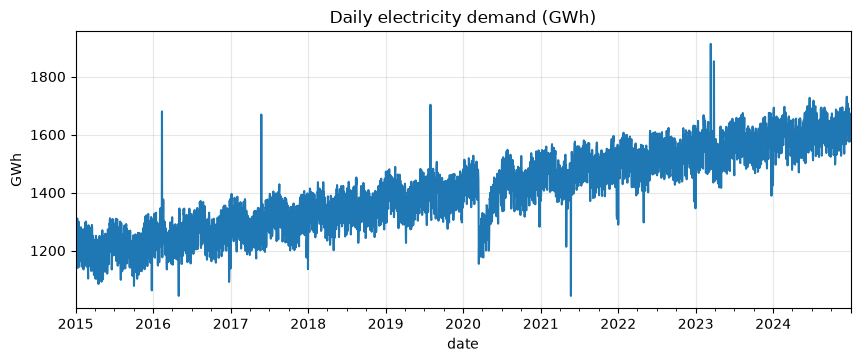

In [3]:
energy = load_energy()
y = energy["demand_gwh"]
y.plot(title="Daily electricity demand (GWh)")
plt.ylabel("GWh")
plt.show()

## 2. Visualizing trend and seasonal variation

STL (Seasonal-Trend decomposition using Loess) splits the series into trend, seasonal, and remainder. The weekly pattern has period 7.

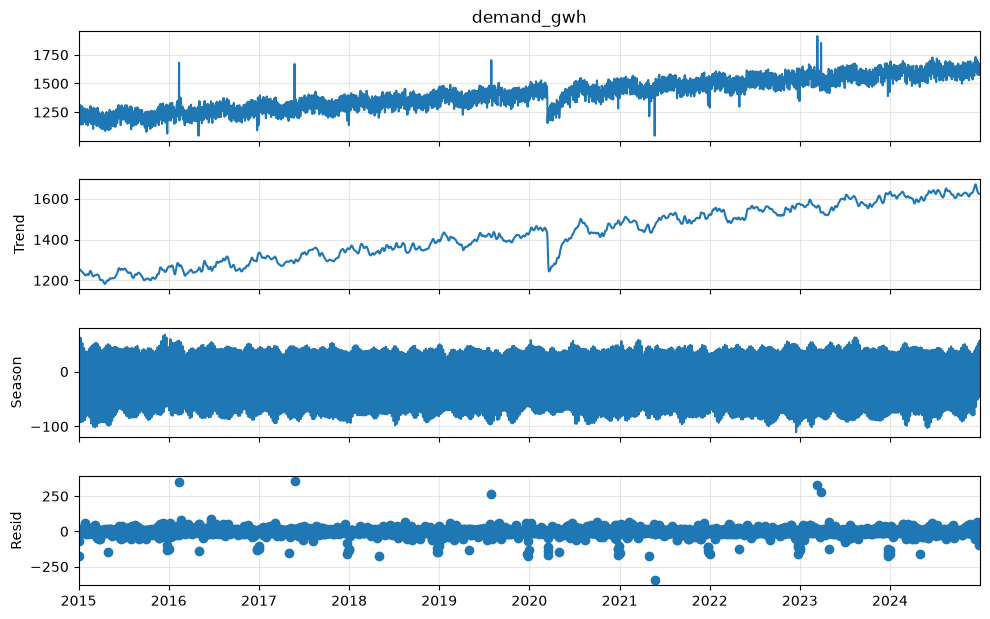

In [4]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(10, 7)
plt.show()

The trend rises slowly. The weekly part repeats every 7 days. Zoom in on one month to see the weekend dip.

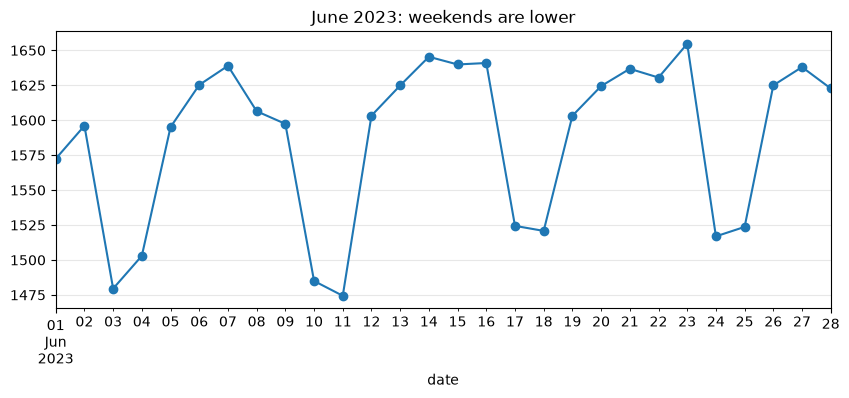

In [5]:
y["2023-06-01":"2023-06-28"].plot(marker="o", title="June 2023: weekends are lower")
plt.show()

The annual cycle is easier to see on monthly means. Demand rises in winter and summer because of heating and cooling.

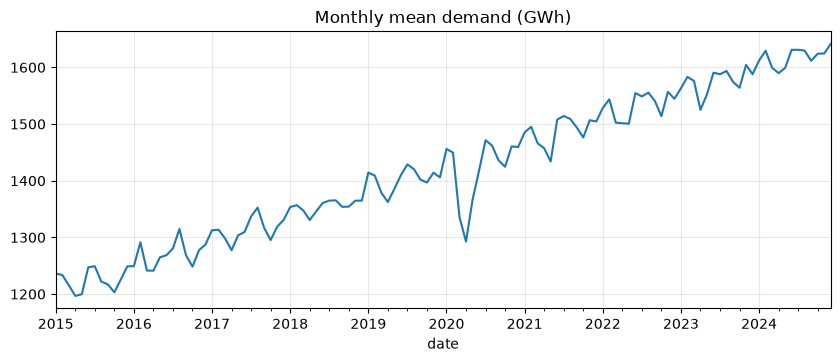

In [6]:
monthly = y.resample("MS").mean()
monthly.plot(title="Monthly mean demand (GWh)")
plt.show()

## 3. Weak stationarity

A series $y_t$ is **weakly stationary** if three conditions hold:

1. The mean is constant: $E[y_t] = \mu$ for all $t$.
2. The variance is finite and constant: $\mathrm{Var}(y_t) = \sigma^2 < \infty$.
3. The covariance depends only on the lag $h$: $\mathrm{Cov}(y_t, y_{t+h}) = \gamma(h)$.

A series with a trend breaks condition 1. A series with growing swings breaks condition 2. Rolling statistics give a quick visual check.

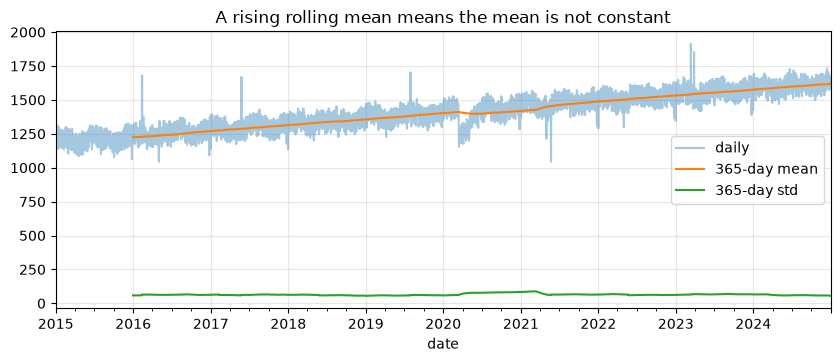

In [7]:
roll = y.rolling(365)
fig, ax = plt.subplots()
y.plot(ax=ax, alpha=0.4, label="daily")
roll.mean().plot(ax=ax, label="365-day mean")
roll.std().plot(ax=ax, label="365-day std")
ax.legend()
ax.set_title("A rising rolling mean means the mean is not constant")
plt.show()

## 4. The Augmented Dickey-Fuller test

The ADF test has a **null hypothesis of a unit root** (non-stationary). A small p-value (below 0.05) rejects the null, which is evidence of stationarity. Use `regression="c"` for a constant and `"ct"` for a constant and trend.

The test is weak against some alternatives. Pair it with the KPSS test, which has the opposite null (stationary).

In [8]:
adf(y, "daily demand (level)")
adf(y, "daily demand (level, trend)", regression="ct")

daily demand (level)         ADF =   -1.29   p = 0.6321   lags = 28  -> cannot reject the unit root (looks non-stationary)
daily demand (level, trend)  ADF =   -7.22   p = 0.0000   lags = 29  -> reject the unit root (looks stationary)


**Two different answers, and both are useful.** With a constant only, the test cannot reject a unit root. With a constant and a linear trend, it rejects. The second result says the series is **trend-stationary**: a straight-line trend plus stationary swings around it. Our data was built that way.

For a trend-stationary series you have two valid choices. You can remove the trend with a regression, or you can difference. Differencing a trend-stationary series works, but it over-differences the noise. In practice, check the ACF after differencing and watch for a large negative spike at lag 1. Real data often sits between the two cases, so state your choice and test it.

## 5. Transforming a non-stationary series with differencing

The first difference $\nabla y_t = y_t - y_{t-1}$ removes a stochastic trend. The seasonal difference $y_t - y_{t-7}$ removes a weekly pattern.

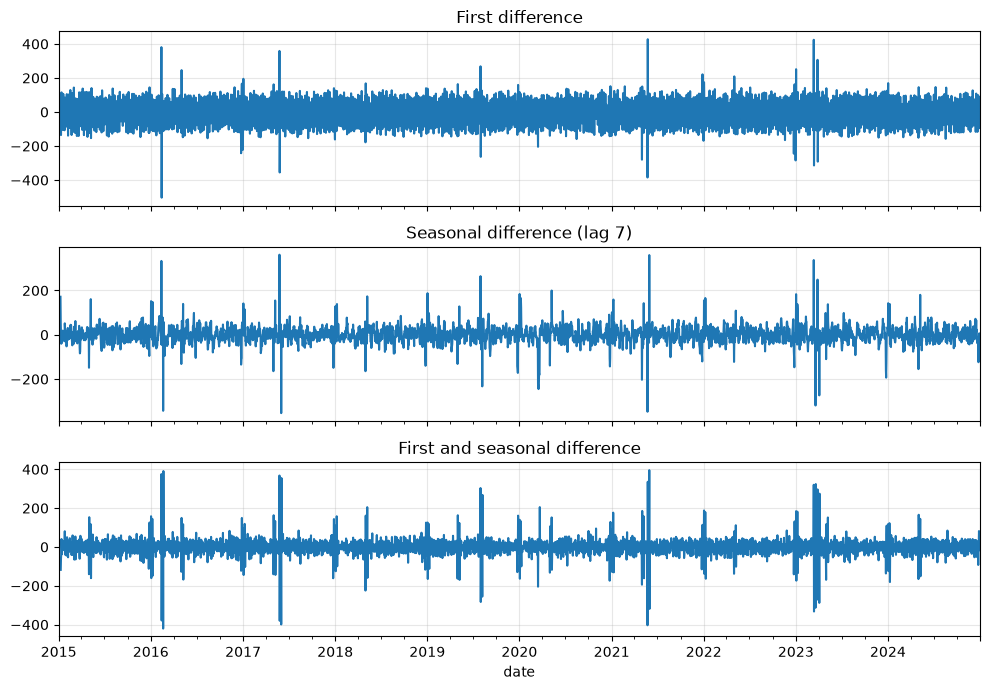

first difference             ADF =  -14.46   p = 0.0000   lags = 27  -> reject the unit root (looks stationary)
seasonal difference (7)      ADF =  -11.88   p = 0.0000   lags = 30  -> reject the unit root (looks stationary)
first + seasonal difference  ADF =  -20.51   p = 0.0000   lags = 30  -> reject the unit root (looks stationary)


In [9]:
d1 = y.diff()
d7 = y.diff(7)
d1_7 = y.diff().diff(7)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
d1.plot(ax=axes[0], title="First difference")
d7.plot(ax=axes[1], title="Seasonal difference (lag 7)")
d1_7.plot(ax=axes[2], title="First and seasonal difference")
plt.tight_layout()
plt.show()

adf(d1, "first difference")
adf(d7, "seasonal difference (7)")
adf(d1_7, "first + seasonal difference")

**Read the result.** All differenced versions pass the ADF test. The level passes only when you allow a trend, as the last section showed.

**Warning on over-differencing.** Each extra difference adds noise and creates a negative spike at lag 1 in the ACF. Use the smallest number of differences that gives a stationary series. The KPSS test gives a second opinion.

In [10]:
from statsmodels.tsa.stattools import kpss

warnings.filterwarnings("ignore", message="The test statistic is outside")  # p-value is clipped at 0.01 and 0.10

for label, s in [("level", y), ("first difference", d1.dropna())]:
    stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
    verdict = "reject stationarity" if p < 0.05 else "cannot reject stationarity"
    print(f"KPSS {label:<18} stat = {stat:.3f}   p = {p:.3f} -> {verdict}")

KPSS level              stat = 9.351   p = 0.010 -> reject stationarity
KPSS first difference   stat = 0.016   p = 0.100 -> cannot reject stationarity


## 6. Variance stabilization with Box-Cox

If the size of the swings grows with the level, the variance is not constant. The Box-Cox transform

$$
y^{(\lambda)} = \begin{cases} \dfrac{y^\lambda - 1}{\lambda} & \lambda \ne 0 \\ \ln y & \lambda = 0 \end{cases}
$$

picks $\lambda$ by maximum likelihood. The energy series has roughly constant swings, so it does not need a transform. The next cell builds a series where the swings grow with the level, which is common in counts, prices, and traffic.

estimated lambda = 0.01  (near 0 means a log transform)


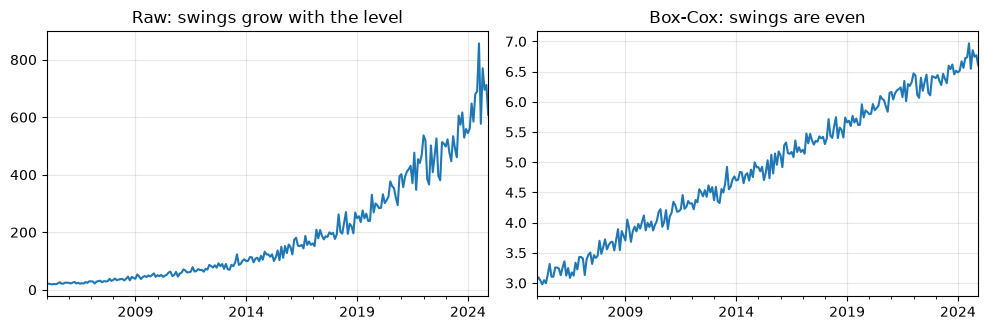

In [11]:
from scipy import stats

rng = np.random.default_rng(7)
t = np.arange(240)
level = np.exp(0.015 * t + 3)
growing = pd.Series(level * np.exp(rng.normal(0, 0.12, t.size)),
                    index=pd.date_range("2005-01-01", periods=t.size, freq="MS"))

transformed, lam = stats.boxcox(growing.values)
print(f"estimated lambda = {lam:.2f}  (near 0 means a log transform)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
growing.plot(ax=axes[0], title="Raw: swings grow with the level")
pd.Series(transformed, index=growing.index).plot(ax=axes[1], title="Box-Cox: swings are even")
plt.tight_layout()
plt.show()

**Remember to invert.** After you forecast on the transformed scale, convert forecasts and intervals back with `scipy.special.inv_boxcox`. Report errors on the original scale.

## Take-home

- Plot first. Decide what you see before you test.
- Use ADF and KPSS together.
- Difference as little as possible.
- Transform for variance before you difference.

**Next:** notebook 02 simulates AR and MA processes and teaches you to read the ACF and PACF.